# Indonesia Temperature Forecast — BMKG + LightGBM

Hourly temperature forecasting for Indonesian cities, combining live **BMKG** forecasts with **Open-Meteo** (ERA5) historical data and a **LightGBM** regression model.

The model is **direct multi-horizon**: from a single forecast origin (a cutoff "as of" timestamp), it predicts every hour from 1 to 336 hours (14 days) ahead in one shot, using only information known at/before that origin — no future data leaks into the features. Accuracy is validated with **rollback testing**: many historical origins are walked forward, each one forecasting 14 days ahead, scored against what actually happened.

**Pipeline:** fetch data → resolve forecast origin window → feature engineering → build rolling-origin datasets → train LightGBM → backtest & live forecast → visualize

> Run the cells top to bottom.

In [1]:
# # Install all required libraries
# import subprocess, sys
#
# packages = [
#     "lightgbm", "pandas", "numpy", "matplotlib",
#     "scikit-learn", "requests", "pyarrow", "joblib"
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
#
# print("All libraries installed.")

## 1. Imports & Configuration

In [ ]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image, HTML

warnings.filterwarnings("ignore")

# Add the code directory to the Python path
# (adjust if the notebook isn't in the same folder as the .py files)
CODE_DIR = "code"   # change if needed, e.g. "/path/to/bmkg_forecast"
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

# ─── MAIN CONFIGURATION ────────────────────────────────────────────────────
# END_TRAIN / TARGET_DATE: leave as None to resolve automatically from the
# latest data actually available (see Section 3) instead of a hardcoded
# date that goes stale. Set them explicitly only to reproduce a specific
# historical experiment.
CONFIG = {
    "END_TRAIN":         None,
    "TARGET_DATE":       None,
    "STATIONS":          ["Jakarta"],  # "Surabaya", "Bandung"

    "HISTORICAL_START":  "2019-01-01",
    "FORCE_REFRESH":     False,
    "SAVE_MODEL":        True,
    "SHOW_PLOTS":        False,
    "OUTPUT_DIR":        "result",

    "ORIGIN_STRIDE_HOURS":        24,   # jarak antar forecast origin (jam)
    "FORECAST_HORIZON_HOURS":     336,  # 14 hari ke depan per origin
    "TRAIN_BACKTEST_BUFFER_DAYS": 45,   # dipakai kalau END_TRAIN None
    "LIVE_ORIGIN":       None,          # None = data terbaru yang tersedia
}
os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"   {k:28s}: {v}")

## 2. Fetch Data — BMKG & Open-Meteo

Historical hourly temperature comes from **Open-Meteo** (ERA5 reanalysis, since 2019); short-term forecasts come from **BMKG**. Results are cached to `.parquet` files under `data/` so the notebook doesn't need to re-fetch on every run.

In [3]:
from data_fetcher import fetch_all_stations, STATIONS

print("Fetching data...")
print(f"   Stations : {CONFIG['STATIONS']}")
print(f"   Period   : {CONFIG['HISTORICAL_START']} → today")
print(f"   Refresh  : {CONFIG['FORCE_REFRESH']}\n")

raw_data = fetch_all_stations(
    stations         = {k: v for k, v in STATIONS.items() if k in CONFIG["STATIONS"]},
    historical_start = CONFIG["HISTORICAL_START"],
    force_refresh    = CONFIG["FORCE_REFRESH"],
)

# ─── Data preview ──────────────────────────────────────────────────────────
print("\nData summary:")
print("-" * 70)
for name, df in raw_data.items():
    if df.empty:
        print(f"  !  {name}: EMPTY")
    else:
        src_counts = df["source"].value_counts().to_dict() if "source" in df.columns else {}
        print(f"  ok {name}: {len(df):,} rows | "
              f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()} | "
              f"Source: {src_counts}")
print("-" * 70)

2026-08-05 03:30:57,803 - INFO - [Cache] Loading Jakarta dari data\jakarta_raw.parquet


Fetching data...
   Stations : ['Jakarta']
   Period   : 2019-01-01 → today
   Refresh  : False


Data summary:
----------------------------------------------------------------------
  ok Jakarta: 64,147 rows | 2019-01-01 → 2026-05-04 | Source: {'openmeteo_historical': 64128, 'bmkg_forecast': 19}
----------------------------------------------------------------------


Station: Jakarta
Shape  : (64147, 8)
Columns: ['timestamp', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'station', 'source', 'weather_code']



,timestamp,temperature,humidity,wind_speed,source
64137,2026-05-03 20:00:00,26.0,91.0,3.5,bmkg_forecast
64138,2026-05-03 23:00:00,25.0,93.0,1.8,bmkg_forecast
64139,2026-05-04 02:00:00,25.0,95.0,1.9,bmkg_forecast
64140,2026-05-04 05:00:00,24.0,96.0,3.4,bmkg_forecast
64141,2026-05-04 08:00:00,28.0,82.0,3.4,bmkg_forecast
64142,2026-05-04 11:00:00,29.0,76.0,5.4,bmkg_forecast
64143,2026-05-04 14:00:00,28.0,80.0,5.4,bmkg_forecast
64144,2026-05-04 17:00:00,26.0,91.0,4.8,bmkg_forecast
64145,2026-05-04 20:00:00,25.0,92.0,4.8,bmkg_forecast
64146,2026-05-04 23:00:00,25.0,94.0,4.3,bmkg_forecast


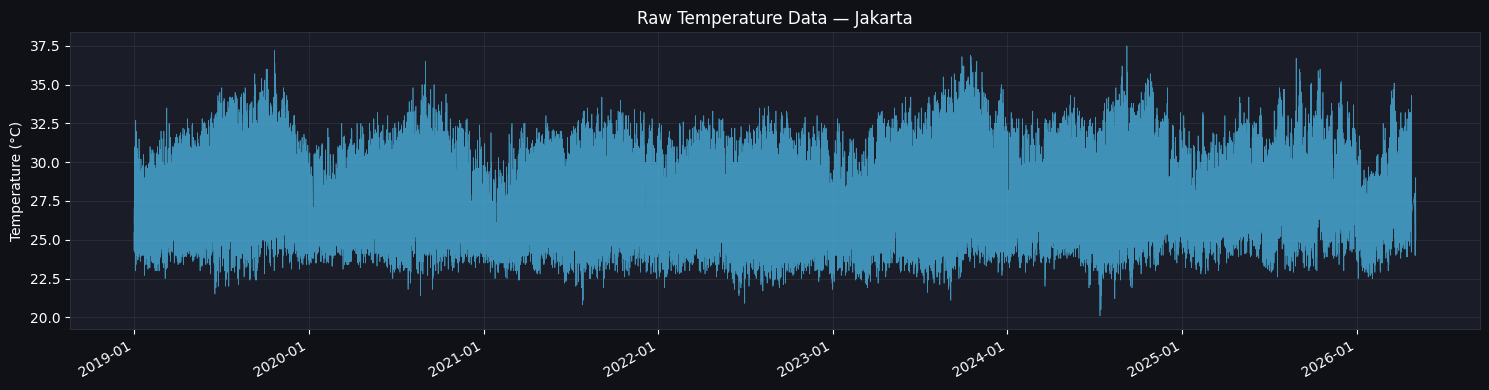

Plot saved.


In [4]:
first_station = CONFIG["STATIONS"][0]
df_raw_sample = raw_data[first_station]

print(f"Station: {first_station}")
print(f"Shape  : {df_raw_sample.shape}")
print(f"Columns: {list(df_raw_sample.columns)}")
print()
display(df_raw_sample[["timestamp", "temperature", "humidity", "wind_speed", "source"]].tail(10))

# Plot raw data
fig, ax = plt.subplots(figsize=(15, 4), facecolor="#0f1117")
ax.set_facecolor("#1a1d27")
ax.plot(df_raw_sample["timestamp"], df_raw_sample["temperature"],
        color="#4fc3f7", lw=0.5, alpha=0.7)
ax.set_title(f"Raw Temperature Data — {first_station}", color="white")
ax.set_ylabel("Temperature (°C)", color="white")
ax.tick_params(colors="white")
ax.spines[:].set_color("#2a2d3a")
ax.grid(True, alpha=0.15, color="gray")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/{first_station.lower()}_raw_data.png", dpi=120, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Plot saved.")

## 3. Resolve Forecast Origin Window

The whole pipeline is built around a **forecast origin**: a single "as of" cutoff timestamp. The model may only use information known at/before the origin, and always predicts exactly `FORECAST_HORIZON_HOURS` (14 days) ahead of it.

- **`END_TRAIN`** — origins up to this date are used to train the model.
- **`TARGET_DATE`** — origins between `END_TRAIN` and `TARGET_DATE − 14d` are used for a **rollback (walk-forward) backtest**: each one forecasts 14 days ahead, and since that period has already happened, the forecast is scored against what actually occurred.

Both default to `None` in the config above, which resolves them from whatever data was actually just fetched — so this never runs against a stale hardcoded date.

In [5]:
from main_bmkg_forecast import resolve_dates, validate_dates

end_train, target_date = resolve_dates(
    raw_data,
    CONFIG["END_TRAIN"], CONFIG["TARGET_DATE"], CONFIG["TRAIN_BACKTEST_BUFFER_DAYS"],
)
validate_dates(end_train, target_date, CONFIG["FORECAST_HORIZON_HOURS"])
CONFIG["END_TRAIN"], CONFIG["TARGET_DATE"] = end_train, target_date

print(f"END_TRAIN   : {end_train}   (training origins up to here)")
print(f"TARGET_DATE : {target_date}   (backtest window ends here)")

2026-08-05 03:31:16,649 - INFO - Period: train origins <= 2026-03-20 | backtest origins 2026-03-20 -> 2026-05-04 (horizon 336h)


END_TRAIN   : 2026-03-20   (training origins up to here)
TARGET_DATE : 2026-05-04   (backtest window ends here)


## 4. Feature Engineering

Two groups of features, built around a forecast origin T0:

| Category | Features | Anchored to |
|---|---|---|
| **Origin state** | lag suhu (t-1, t-3, t-6, t-12, t-24, t-48, t-72h), rolling mean/std/min/max (7/14/30/60/90 hari), momentum (t-6h, t-24h), humidity/wind/precipitation saat origin + lag-1/lag-24h | Data ≤ T0 — broadcast ke seluruh horizon origin tsb. |
| **Target calendar** | sin/cos jam, hari-minggu, hari-bulan, bulan, hari-tahun; hour, dayofweek, month, year, quarter, is_weekend, is_rainy_season | Timestamp target (T0 + h) — selalu bisa diketahui lebih dulu. |
| **Horizon** | `horizon_h` (1–336) | — |
| **Climatology** | rata-rata & std suhu historis per (bulan, tanggal), dihitung dari data ≤ END_TRAIN | Target's (month, day). |

Raw same-timestamp humidity/wind/precipitation and target-relative lag features are **not** used as of the target time — those aren't knowable days in advance, which was the source of the leakage this pipeline used to have.

In [6]:
from preprocessing import run_preprocessing, get_feature_columns

processed_data = {}

for name, df_raw in raw_data.items():
    if df_raw.empty:
        print(f"  !  {name}: skipped (empty data)")
        continue
    print(f"  >  Preprocessing {name} ...", end=" ")
    df_proc = run_preprocessing(df_raw, station_name=name, drop_na=True)
    processed_data[name] = df_proc
    print(f"ok  {len(df_proc):,} origin rows | {len(get_feature_columns(df_proc))} state features")

print("\nPreprocessing complete for all stations.")

# ─── Inspect one station's origin-state table ───────────────────────────────
first_station  = CONFIG["STATIONS"][0]
df_proc_sample = processed_data[first_station]
feat_cols      = get_feature_columns(df_proc_sample)

print(f"\nOrigin-state features for {first_station}: {len(feat_cols)}")
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:3d}. {c}")

print("\nSample origin-state rows:")
display(df_proc_sample[["timestamp", "temperature",
                          "lag_24h", "roll_mean_7d",
                          "momentum_24h", "humidity_at_origin"]].tail(5))

2026-08-05 03:31:16,665 - INFO - [Preprocessing] Starting for station: Jakarta | initial rows: 64147
2026-08-05 03:31:16,724 - INFO - Resampled to hourly: 64344 rows.


  >  Preprocessing Jakarta ... 

2026-08-05 03:31:16,882 - INFO - [Preprocessing] Done: 63060/64344 valid origin rows.


ok  63,060 origin rows | 38 state features

Preprocessing complete for all stations.

Origin-state features for Jakarta: 38
    1. lag_1h
    2. lag_3h
    3. lag_6h
    4. lag_12h
    5. lag_24h
    6. lag_48h
    7. lag_72h
    8. roll_mean_7d
    9. roll_std_7d
   10. roll_min_7d
   11. roll_max_7d
   12. roll_mean_14d
   13. roll_std_14d
   14. roll_min_14d
   15. roll_max_14d
   16. roll_mean_30d
   17. roll_std_30d
   18. roll_min_30d
   19. roll_max_30d
   20. roll_mean_60d
   21. roll_std_60d
   22. roll_min_60d
   23. roll_max_60d
   24. roll_mean_90d
   25. roll_std_90d
   26. roll_min_90d
   27. roll_max_90d
   28. momentum_6h
   29. momentum_24h
   30. humidity_at_origin
   31. humidity_lag1
   32. humidity_lag24
   33. wind_speed_at_origin
   34. wind_speed_lag1
   35. wind_speed_lag24
   36. precipitation_at_origin
   37. precipitation_lag1
   38. precipitation_lag24

Sample origin-state rows:


,timestamp,temperature,lag_24h,roll_mean_7d,momentum_24h,humidity_at_origin
63055,2026-04-26 07:00:00,26.748148,26.9,28.458433,-0.151852,91.0
63056,2026-04-26 08:00:00,26.748148,28.6,28.462886,-1.851852,91.0
63057,2026-04-26 09:00:00,26.748148,30.5,28.456030,-3.751852,91.0
63058,2026-04-26 10:00:00,26.748148,32.0,28.437864,-5.251852,91.0
63059,2026-04-26 11:00:00,26.748148,33.2,28.413150,-6.451852,91.0


## 5. Build Training / Backtest / Live Datasets (Rolling-Origin)

Each forecast origin gets expanded into up to `FORECAST_HORIZON_HOURS` rows (one per hour ahead), pairing the origin's state with the target hour's calendar features, climatology, and (if it already happened) the actual recorded temperature.

- **Training set** — origins from the start of history up to `END_TRAIN`, sampled every `ORIGIN_STRIDE_HOURS` hours.
- **Backtest set** — origins between `END_TRAIN` and `TARGET_DATE − 14d`; this is the rollback test.
- **Live set** — a single origin (`LIVE_ORIGIN`, default: latest available data) with no actual outcome yet — this produces the real 14-day forecast.

In [7]:
from preprocessing import select_origins, build_climatology, build_direct_horizon_frame, TARGET_COL

datasets = {}
backtest_end = pd.to_datetime(CONFIG["TARGET_DATE"]) - pd.Timedelta(hours=CONFIG["FORECAST_HORIZON_HOURS"])

for name, df_state in processed_data.items():
    df_actual = df_state[["timestamp", TARGET_COL]].copy()
    clim = build_climatology(df_actual, as_of=CONFIG["END_TRAIN"])

    train_origins    = select_origins(df_state, end=CONFIG["END_TRAIN"], stride_hours=CONFIG["ORIGIN_STRIDE_HOURS"])
    backtest_origins = select_origins(df_state, start=CONFIG["END_TRAIN"], end=backtest_end, stride_hours=CONFIG["ORIGIN_STRIDE_HOURS"])

    df_train    = build_direct_horizon_frame(df_state, df_actual, train_origins, clim, CONFIG["FORECAST_HORIZON_HOURS"])
    df_backtest = build_direct_horizon_frame(df_state, df_actual, backtest_origins, clim, CONFIG["FORECAST_HORIZON_HOURS"])

    live_cutoff     = pd.to_datetime(CONFIG["LIVE_ORIGIN"]) if CONFIG["LIVE_ORIGIN"] else df_state["timestamp"].max()
    live_candidates = select_origins(df_state, end=live_cutoff, stride_hours=1)
    df_live         = (build_direct_horizon_frame(df_state, df_actual, live_candidates.iloc[[-1]], clim, CONFIG["FORECAST_HORIZON_HOURS"])
                        if not live_candidates.empty else pd.DataFrame())

    datasets[name] = {"train": df_train, "backtest": df_backtest, "live": df_live, "climatology": clim, "actual": df_actual}
    print(f"  ok  {name}: train={len(df_train):,} rows | backtest={len(df_backtest):,} rows | live={len(df_live):,} rows")

print("\nDatasets built for all stations.")

2026-08-05 03:31:16,930 - INFO - [Climatology] Built from data <= 2026-03-20: 366 (month, day) buckets.
2026-08-05 03:31:19,013 - INFO - [DirectHorizon] Built 870,576 rows from 2,591 origins x up to 336h horizon.
2026-08-05 03:31:19,117 - INFO - [DirectHorizon] Built 10,752 rows from 32 origins x up to 336h horizon.
2026-08-05 03:31:19,196 - INFO - [DirectHorizon] Built 336 rows from 1 origins x up to 336h horizon.


  ok  Jakarta: train=870,576 rows | backtest=10,752 rows | live=336 rows

Datasets built for all stations.


## 6. Train LightGBM Model

One model per station, trained on the rolling-origin training set (`horizon_h` is one of the features, so a single model learns behavior across the whole 14-day horizon). Validation is held out by **origin** (last 10% of origins), not by row, so no origin's data leaks between train and validation.

In [8]:
from model import TemperatureForecastModel

models = {}

for name, ds in datasets.items():
    print(f"\n{'='*55}")
    print(f" Training: {name}")
    print(f"{'='*55}")

    mdl = TemperatureForecastModel(
        station     = name,
        end_train   = CONFIG["END_TRAIN"],
        target_date = CONFIG["TARGET_DATE"],
    )
    mdl.climatology_ = ds["climatology"]
    mdl.fit(ds["train"])
    models[name] = mdl
    print(f"  ok  Model {name} trained.")

print("\nAll models trained.")

2026-08-05 03:31:19,218 - INFO - [Model] Feature columns: 57 features



 Training: Jakarta


2026-08-05 03:31:19,881 - INFO - [Model] Origins: 2591 total, 2332 train / 259 val | Rows: 783552 train / 87024 val
2026-08-05 03:31:31,678 - INFO - [Metrics-Train] MAE=0.743°C | RMSE=0.957°C | MAPE=2.73% | R²=0.8787
2026-08-05 03:31:31,781 - INFO - [Metrics-Validation] MAE=1.147°C | RMSE=1.494°C | MAPE=4.14% | R²=0.6846


  ok  Model Jakarta trained.

All models trained.


## 7. Backtest (Rollback Testing) & Live Forecast

`predict_backtest` scores every rollback origin's 14-day forecast against what actually happened; `metrics_by_horizon` breaks that down by day 1–14 so horizon-dependent skill decay is visible instead of hidden behind a single averaged number. `predict_live` runs the same model on the current origin to produce the actual 14-day-ahead deliverable, which has no recorded outcome yet.

In [9]:
results = {}

for name, mdl in models.items():
    ds = datasets[name]
    print(f"\n── {name} ─────────────────────────────")

    backtest_result = mdl.predict_backtest(ds["backtest"])
    metrics    = mdl.get_metrics() if not backtest_result.empty else {}
    by_horizon = mdl.metrics_by_horizon(backtest_result)

    live_result = mdl.predict_live(ds["live"]) if not ds["live"].empty else pd.DataFrame()

    csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_backtest_predictions.csv")
    backtest_result.to_csv(csv_path, index=False)

    live_csv_path = ""
    if not live_result.empty:
        live_csv_path = os.path.join(CONFIG["OUTPUT_DIR"], f"{name.lower()}_forecast_next14d.csv")
        live_result.to_csv(live_csv_path, index=False)

    results[name] = {
        "model": mdl, "metrics": metrics, "by_horizon": by_horizon,
        "backtest": backtest_result, "live": live_result,
        "csv_path": csv_path, "live_csv_path": live_csv_path,
    }
    print(f"  MAE  = {metrics.get('mae',  0):.3f}°C")
    print(f"  RMSE = {metrics.get('rmse', 0):.3f}°C")
    print(f"  MAPE = {metrics.get('mape', 0):.2f}%")
    print(f"  R²   = {metrics.get('r2',   0):.4f}")
    print(f"  Backtest CSV : {csv_path}")
    print(f"  Live CSV     : {live_csv_path or '(no live origin)'}")

print("\nBacktest + live forecast complete.")

# ─── Summary across all stations ────────────────────────────────────────────
summary_rows = []
for name, res in results.items():
    m = res["metrics"]
    summary_rows.append({
        "Station":   name,
        "MAE (°C)":  round(m.get("mae",  np.nan), 3),
        "RMSE (°C)": round(m.get("rmse", np.nan), 3),
        "MAPE (%)":  round(m.get("mape", np.nan), 2),
        "R²":        round(m.get("r2",   np.nan), 4),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

summary_path = os.path.join(CONFIG["OUTPUT_DIR"], "summary_metrics.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

2026-08-05 03:31:31,928 - INFO - [Metrics-Backtest] MAE=0.875°C | RMSE=1.157°C | MAPE=3.09% | R²=0.7751
2026-08-05 03:31:31,936 - INFO - [Metrics-Backtest-Final] MAE=0.875°C | RMSE=1.157°C | MAPE=3.09% | R²=0.7751



── Jakarta ─────────────────────────────
  MAE  = 0.875°C
  RMSE = 1.157°C
  MAPE = 3.09%
  R²   = 0.7751
  Backtest CSV : output\jakarta_backtest_predictions.csv
  Live CSV     : output\jakarta_forecast_next14d.csv

Backtest + live forecast complete.


,Station,MAE (°C),RMSE (°C),MAPE (%),R²
0,Jakarta,0.875,1.157,3.09,0.7751



Summary saved to: output\summary_metrics.csv


## 8. Visualize Results

- **Skill vs horizon day** — backtest MAE/RMSE for each of the 14 forecast days. A gradual increase is the expected, honest signature of a real multi-day forecast; a flat near-zero line at every horizon would mean the model is leaking.
- **Forecast fan** — trailing actual history plus the live 14-day forecast for one origin (with real outcomes overlaid when it's a backtest origin instead of the live one).


Plots for Jakarta:


2026-08-05 03:31:32,492 - INFO - [Plot] Skill-by-horizon chart saved to: output\jakarta_skill_by_horizon.png


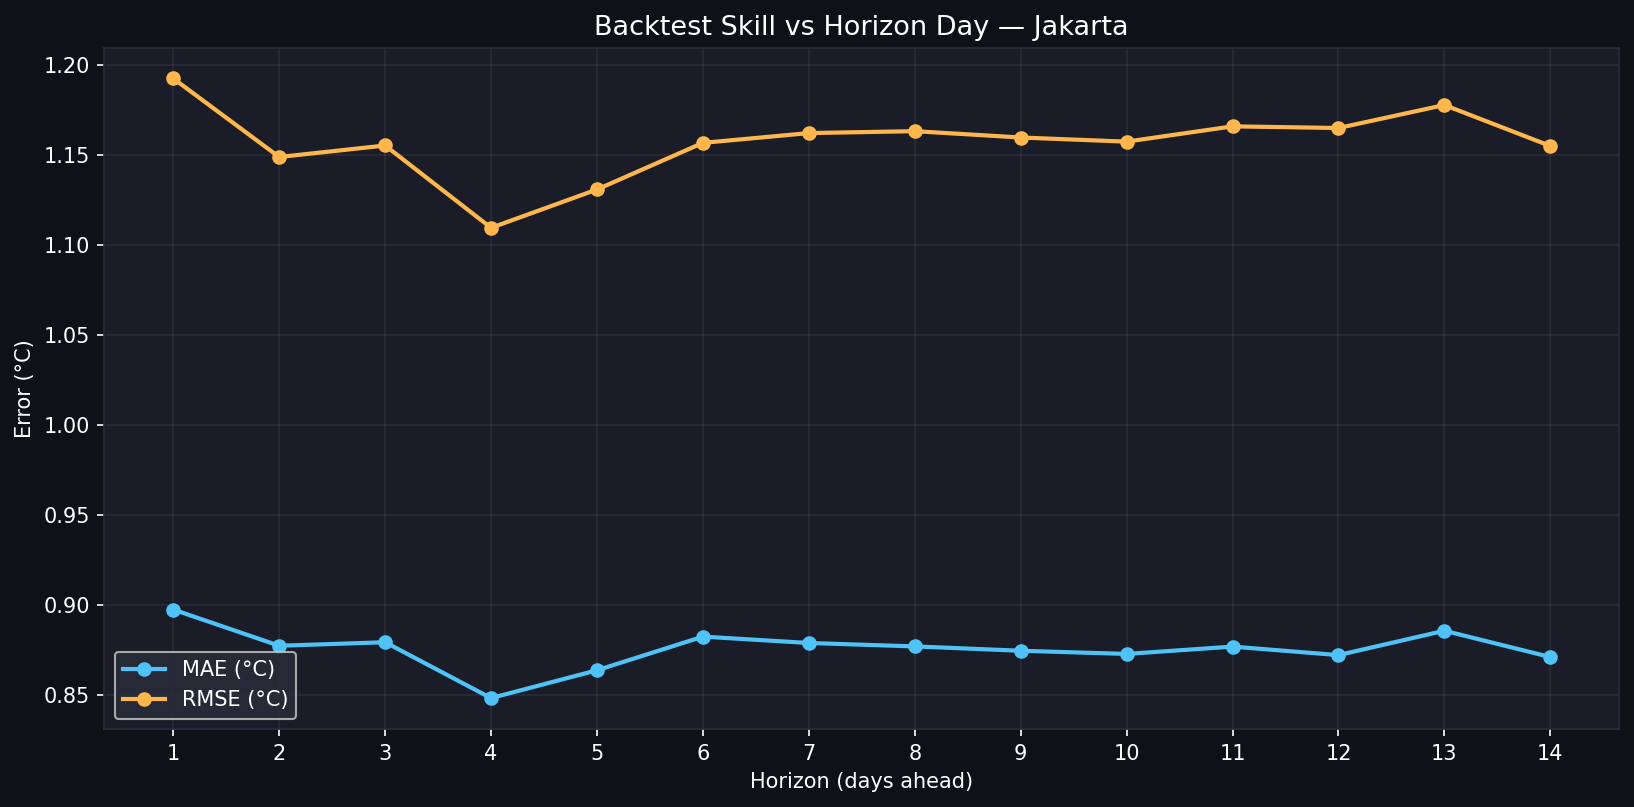

2026-08-05 03:31:32,866 - INFO - [Plot] Forecast-fan chart saved to: output\jakarta_forecast_fan.png


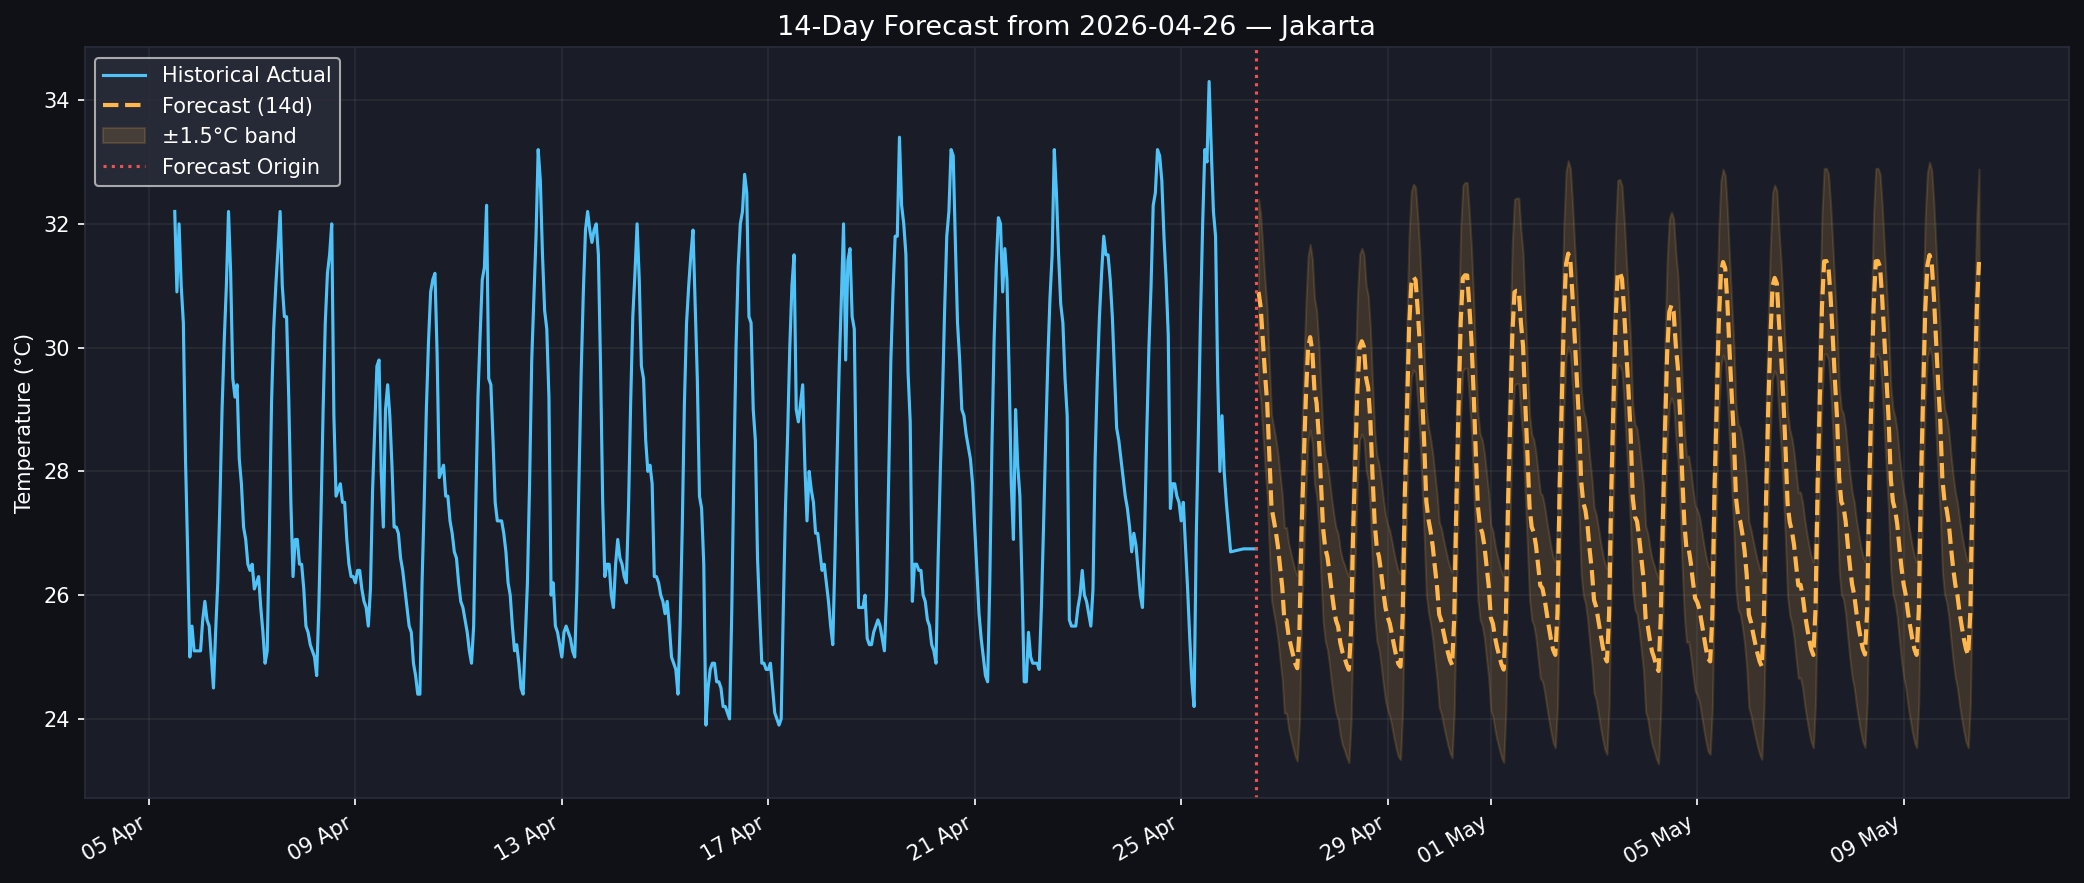

In [10]:
for name, res in results.items():
    mdl = res["model"]

    print(f"\nPlots for {name}:")
    img_skill = mdl.plot_skill_by_horizon(res["backtest"], save=True, show=CONFIG["SHOW_PLOTS"])
    if img_skill and os.path.exists(img_skill):
        display(Image(img_skill))

    if not res["live"].empty:
        img_fan = mdl.plot_forecast_fan(datasets[name]["actual"], res["live"], save=True, show=CONFIG["SHOW_PLOTS"])
        if img_fan and os.path.exists(img_fan):
            display(Image(img_fan))

## 9. Feature Importance Analysis

2026-08-05 03:31:33,208 - INFO - [Plot] Feature importance chart saved to: output\jakarta_feature_importance.png


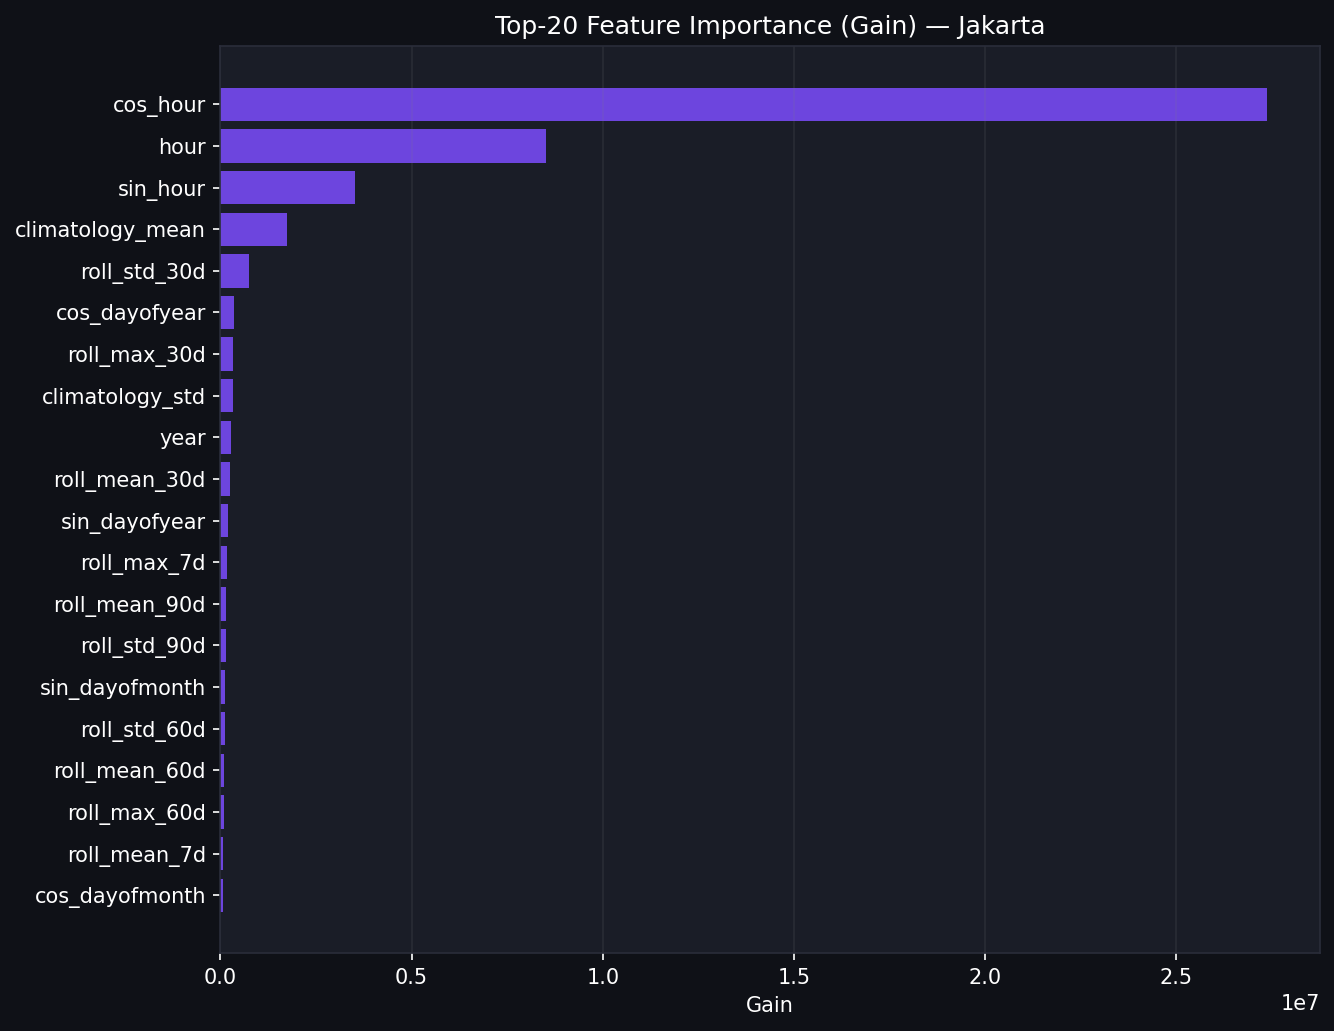

In [11]:
first_station = CONFIG["STATIONS"][0]
mdl = results[first_station]["model"]

img_path = mdl.plot_feature_importance(top_n=20, save=True, show=CONFIG["SHOW_PLOTS"])
if img_path and os.path.exists(img_path):
    display(Image(img_path))

## 10. Save Model

In [12]:
if CONFIG["SAVE_MODEL"]:
    for name, res in results.items():
        path = res["model"].save_model()
        print(f"  ok  {name} saved → {path}")
else:
    print("SAVE_MODEL=False, model not saved.")

2026-08-05 03:31:33,259 - INFO - [Model] Saved to: output\lgbm_jakarta.pkl


  ok  Jakarta saved → output\lgbm_jakarta.pkl


## (Optional) Run via Full Orchestrator

Runs the entire pipeline at once through `main_bmkg_forecast.run_pipeline()` — useful for re-running with a different configuration without repeating each cell above.

In [13]:
# ─── UNCOMMENT to run the full pipeline via the orchestrator ──────────────
# from main_bmkg_forecast import run_pipeline
#
# custom_config = {
#     "END_TRAIN":              None,
#     "TARGET_DATE":            None,
#     "STATIONS":               ["Bandung", "Surabaya"],
#     "HISTORICAL_START":       "2020-01-01",
#     "FORCE_REFRESH":          False,
#     "SAVE_MODEL":             True,
#     "SHOW_PLOTS":             False,
#     "FORECAST_HORIZON_HOURS": 336,
#     "ORIGIN_STRIDE_HOURS":    24,
# }
#
# results_alt = run_pipeline(custom_config)
print("Uncomment the code above to run the full pipeline.")

Uncomment the code above to run the full pipeline.
